# Notebook 5 — Drilling Anomaly Detection

## Real-timestamp Drilling Analysis with Machine Learning

### Objective

This notebook develops an unsupervised machine learning system for detecting
unusual drilling conditions from real-timestamp drilling measurements.

Because a reliable labeled anomaly dataset is not available, the problem is
formulated as an **unsupervised anomaly detection problem**.

The system will:

1. Analyze the available drilling measurements.
2. Select physically meaningful operational features.
3. Handle missing and infinite values.
4. Normalize variables with different numerical scales.
5. Train an Isolation Forest anomaly detector.
6. Generate anomaly scores for future drilling observations.
7. Classify observations as normal or anomalous.
8. Assign anomaly severity levels.
9. Analyze the operating conditions associated with detected anomalies.
10. Generate files for integration with the IntelliWell prediction pipeline.

### Primary Algorithm

**Isolation Forest**

### Main Outputs

Each drilling observation will receive:

- Anomaly Score
- Anomaly Flag
- Anomaly Severity

> **Important:** An anomaly does not automatically indicate equipment failure.
> It indicates that the observed operating condition is unusual relative to
> the reference drilling data and should be investigated further.

## 1. Methodology Overview

The anomaly-detection pipeline follows the workflow below:

**Raw Drilling Data**
↓
**Data Cleaning and Validation**
↓
**Feature Selection**
↓
**Missing/Infinite Value Handling**
↓
**Robust Scaling**
↓
**Chronological Reference Period**
↓
**Isolation Forest**
↓
**Anomaly Score**
↓
**Anomaly Flag**
↓
**Severity Classification**
↓
**Operational Analysis**
↓
**Dashboard-Ready Results**

A chronological approach is used so that the anomaly detector is trained on
earlier drilling observations and subsequently applied to later observations.

This better represents how the system would operate in a real-timestamp environment.

## 2. Import Required Libraries

The following libraries are used for:

- Data manipulation
- Numerical computation
- Visualization
- Missing-value handling
- Feature scaling
- Isolation Forest anomaly detection
- Model persistence
- Metadata generation

In [95]:
# ============================================================
# 2. IMPORTS
# ============================================================

import os
import json
import warnings
import joblib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Cleaned Drilling Dataset

The cleaned drilling dataset used in the previous notebooks is loaded.

The same underlying drilling data is used to maintain consistency across the
project's predictive and anomaly-detection modules.

If the dataframe `df` already exists in the notebook environment, it will be
reused.

In [96]:
# ============================================================
# 3. LOAD DATA
# ============================================================

import os
import pandas as pd

# Change this path if your CSV is stored elsewhere
csv_path = "drilling_data_cleaned.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"Dataset not found:\n{csv_path}\n\n"
        "Please provide the correct path to drilling_data_cleaned.csv."
    )

df = pd.read_csv(csv_path)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Rows    :", f"{len(df):,}")
print("Columns :", len(df.columns))

display(df.head())

DATASET LOADED SUCCESSFULLY
Rows    : 598,709
Columns : 37


,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,pump_pressure,...,depth_hole_tvd,differential_pressure,downhole_torque,drill_mode,year,month,day,hour,day_of_week,timestamp
0,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
1,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
2,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,57.19964,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
3,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,0.00000,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00
4,43.55661,46.948985,123.68008,0.0,0.0,0.0,0.31182,0.0,0.00000,40.23666,...,7389.89,-531.16685,1894.27245,0.0,2020,10,25,12,6,2020-10-25 12:00:00


## 4. Dataset Overview

Before developing the anomaly detector, the structure and quality of the
dataset are examined.

This includes:

- Number of observations
- Number of variables
- Available columns
- Data types
- Missing values

This step helps identify variables that should not be supplied to the
anomaly-detection model.

In [97]:
# ============================================================
# 4. BASIC DATASET INSPECTION
# ============================================================

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

Number of rows: 598709
Number of columns: 37

Columns:
['block_position', 'weight_on_bit', 'hookload', 'slips_set', 'rop_depth_hour', 'on_bottom', 'top_drive_rpm', 'top_drive_torque_ft_lbs', 'flow_in', 'pump_pressure', 'spm_total', 'pit_volume_active', 'pit_gl_active', 'gas_total_units', 'trip_volume_active', 'trip_gl', 'return_flow', 'rig_mode', 'rockit_on_off', 'mwd_inclination', 'mwd_azimuth', 'mud_temp', 'h2s_01', 'rig_event_code', 'total_depth', 'bit_diameter', 'bit_rpm', 'depth_hole_tvd', 'differential_pressure', 'downhole_torque', 'drill_mode', 'year', 'month', 'day', 'hour', 'day_of_week', 'timestamp']

Data types:


block_position             float64
weight_on_bit              float64
hookload                   float64
slips_set                  float64
rop_depth_hour             float64
on_bottom                  float64
top_drive_rpm              float64
top_drive_torque_ft_lbs    float64
flow_in                    float64
pump_pressure              float64
spm_total                  float64
pit_volume_active          float64
pit_gl_active              float64
gas_total_units            float64
trip_volume_active         float64
trip_gl                    float64
return_flow                float64
rig_mode                   float64
rockit_on_off              float64
mwd_inclination            float64
mwd_azimuth                float64
mud_temp                   float64
h2s_01                     float64
rig_event_code             float64
total_depth                float64
bit_diameter               float64
bit_rpm                    float64
depth_hole_tvd             float64
differential_pressur


Missing values:


rockit_on_off              199513
mwd_azimuth                 51618
mwd_inclination             51613
gas_total_units             46269
h2s_01                      23231
slips_set                      65
mud_temp                       46
drill_mode                     45
differential_pressure          45
block_position                 45
top_drive_torque_ft_lbs        45
on_bottom                      44
rig_event_code                 28
rig_mode                       28
bit_diameter                    0
day_of_week                     0
hour                            0
day                             0
month                           0
year                            0
hookload                        0
downhole_torque                 0
rop_depth_hour                  0
depth_hole_tvd                  0
bit_rpm                         0
dtype: int64

## 5. timestamp Preparation

Drilling data is inherently timestamp-dependent.

The timestamp is used for:

- Chronological ordering
- Reference/scoring period separation
- Temporal anomaly visualization
- Dashboard integration

The timestamp itself is **not used as a direct model feature**, because
calendar values do not represent the physical drilling state.

In [98]:
# ============================================================
# 5. TIMESTAMP PREPARATION
# ============================================================

if "timestamp" not in df.columns:

    raise ValueError(
        "timestamp column not found."
    )

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

df = df.dropna(
    subset=["timestamp"]
)

df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

print(
    "Time range:",
    df["timestamp"].min(),
    "→",
    df["timestamp"].max()
)

Time range: 2020-10-25 12:00:00 → 2021-01-05 11:00:00


## 6. Candidate Drilling Features

The anomaly detector uses physical drilling and operational measurements.

Candidate variables include:

- Mechanical drilling parameters
- Hydraulic parameters
- Surface equipment measurements
- Downhole measurements
- Depth-related measurements
- Operational state measurements

Identifiers and timestamps are not considered anomaly features.

The feature list is also checked against the actual dataset so that the
notebook remains robust if a particular variable is unavailable.

In [99]:
# ============================================================
# 6. CANDIDATE FEATURES
# ============================================================

candidate_features = [
    "block_position",
    "weight_on_bit",
    "hookload",
    "slips_set",
    "rop_depth_hour",
    "on_bottom",
    "top_drive_rpm",
    "top_drive_torque_ft_lbs",
    "flow_in",
    "pump_pressure",
    "spm_total",
    "pit_volume_active",
    "pit_gl_active",
    "gas_total_units",
    "trip_volume_active",
    "trip_gl",
    "return_flow",
    "rig_mode",
    "rockit_on_off",
    "mwd_inclination",
    "mwd_azimuth",
    "mud_temp",
    "h2s_01",
    "rig_event_code",
    "total_depth",
    "bit_diameter",
    "bit_rpm",
    "depth_hole_tvd",
    "differential_pressure",
    "downhole_torque"
]

available_features = [
    feature
    for feature in candidate_features
    if feature in df.columns
]

missing_features = [
    feature
    for feature in candidate_features
    if feature not in df.columns
]

print("Available candidate features:")
print(available_features)

print("\nMissing candidate features:")
print(missing_features)

Available candidate features:
['block_position', 'weight_on_bit', 'hookload', 'slips_set', 'rop_depth_hour', 'on_bottom', 'top_drive_rpm', 'top_drive_torque_ft_lbs', 'flow_in', 'pump_pressure', 'spm_total', 'pit_volume_active', 'pit_gl_active', 'gas_total_units', 'trip_volume_active', 'trip_gl', 'return_flow', 'rig_mode', 'rockit_on_off', 'mwd_inclination', 'mwd_azimuth', 'mud_temp', 'h2s_01', 'rig_event_code', 'total_depth', 'bit_diameter', 'bit_rpm', 'depth_hole_tvd', 'differential_pressure', 'downhole_torque']

Missing candidate features:
[]


## 7. Feature Filtering

Not every column in the drilling dataset is suitable for anomaly detection.

The following types of variables are excluded:

- Timestamp
- Calendar variables
- Target labels from other notebooks
- Non-physical identifiers

The objective is to detect unusual **operating conditions**, rather than
unusual row identifiers or timestamps.

In [100]:
# ============================================================
# 7. FEATURE FILTERING
# ============================================================

# Features excluded because they mainly represent
# drilling progression, trajectory, or contextual state.
context_features = [
    "depth_hole_tvd",
    "total_depth",
    "trip_volume_active",
    "trip_gl",
    "mwd_inclination"
]

# Time and previously classified operational label
# are not used as anomaly-detection features.
excluded_features = [
    "timestamp",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week",
    "drill_mode"
]

# Combine all features that should not drive
# the anomaly detector.
all_excluded_features = (
    excluded_features
    + context_features
)

anomaly_features = [
    feature
    for feature in available_features
    if feature not in all_excluded_features
]

print("=" * 70)
print("FEATURE FILTERING")
print("=" * 70)

print("\nExcluded context/progression features:")

for feature in context_features:
    if feature in available_features:
        print(f"  - {feature}")

print("\nExcluded time/label features:")

for feature in excluded_features:
    if feature in available_features:
        print(f"  - {feature}")

print("\nSelected anomaly features:")

for feature in anomaly_features:
    print(f"  - {feature}")

print(
    "\nNumber of candidate features:",
    len(available_features)
)

print(
    "Number of selected features:",
    len(anomaly_features)
)

FEATURE FILTERING

Excluded context/progression features:
  - depth_hole_tvd
  - total_depth
  - trip_volume_active
  - trip_gl
  - mwd_inclination

Excluded time/label features:

Selected anomaly features:
  - block_position
  - weight_on_bit
  - hookload
  - slips_set
  - rop_depth_hour
  - on_bottom
  - top_drive_rpm
  - top_drive_torque_ft_lbs
  - flow_in
  - pump_pressure
  - spm_total
  - pit_volume_active
  - pit_gl_active
  - gas_total_units
  - return_flow
  - rig_mode
  - rockit_on_off
  - mwd_azimuth
  - mud_temp
  - h2s_01
  - rig_event_code
  - bit_diameter
  - bit_rpm
  - differential_pressure
  - downhole_torque

Number of candidate features: 30
Number of selected features: 25


## 8. Numeric Feature Selection

Isolation Forest operates on numerical feature representations.

The candidate features are therefore separated into numeric and non-numeric
variables.

Only numerical physical measurements are used in the initial anomaly
detection model.

In [101]:
# ============================================================
# 8. NUMERIC FEATURES
# ============================================================

numeric_features = [
    feature
    for feature in anomaly_features
    if pd.api.types.is_numeric_dtype(
        df[feature]
    )
]

non_numeric_features = [
    feature
    for feature in anomaly_features
    if feature not in numeric_features
]

print("Numeric features:")
print(numeric_features)

print("\nNon-numeric features:")
print(non_numeric_features)

Numeric features:
['block_position', 'weight_on_bit', 'hookload', 'slips_set', 'rop_depth_hour', 'on_bottom', 'top_drive_rpm', 'top_drive_torque_ft_lbs', 'flow_in', 'pump_pressure', 'spm_total', 'pit_volume_active', 'pit_gl_active', 'gas_total_units', 'return_flow', 'rig_mode', 'rockit_on_off', 'mwd_azimuth', 'mud_temp', 'h2s_01', 'rig_event_code', 'bit_diameter', 'bit_rpm', 'differential_pressure', 'downhole_torque']

Non-numeric features:
[]


## 9. Missing and Infinite Value Analysis

Real-world drilling data may contain:

- Missing sensor readings
- Invalid numerical values
- Infinite values
- Temporary sensor dropouts

These values must be handled before training Isolation Forest.

Missing values are imputed using the median of the reference training
period. The imputer is never fitted using future scoring observations.

In [102]:
# ============================================================
# 9. MISSING AND INFINITE VALUES
# ============================================================

anomaly_df = df[
    ["timestamp"] + numeric_features
].copy()

anomaly_df = anomaly_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Missing values:")

display(
    anomaly_df[numeric_features]
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

Missing values:


rockit_on_off              199513
mwd_azimuth                 51618
gas_total_units             46269
h2s_01                      23231
slips_set                      65
mud_temp                       46
block_position                 45
differential_pressure          45
top_drive_torque_ft_lbs        45
on_bottom                      44
rig_mode                       28
rig_event_code                 28
bit_rpm                         0
bit_diameter                    0
pit_gl_active                   0
return_flow                     0
weight_on_bit                   0
pit_volume_active               0
spm_total                       0
pump_pressure                   0
flow_in                         0
top_drive_rpm                   0
rop_depth_hour                  0
hookload                        0
downhole_torque                 0
dtype: int64

## 10. Descriptive Statistics

Descriptive statistics are calculated for the selected anomaly-detection
features.

This provides an overview of the normal numerical ranges and helps identify
variables with substantially different scales.

In [103]:
# ============================================================
# 10. DESCRIPTIVE STATISTICS
# ============================================================

display(
    anomaly_df[numeric_features]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
block_position,598664.0,44.964887,66.310160,-1511.29480,13.55818,43.55661,79.622410,116.24767
weight_on_bit,598709.0,94.728056,69.802487,0.00000,37.17398,82.41836,172.000180,837.66199
hookload,598709.0,124.848178,114.919024,0.00000,41.66026,123.68008,197.546650,15468.20800
slips_set,598644.0,0.452028,0.497694,0.00000,0.00000,0.00000,1.000000,1.00000
rop_depth_hour,598709.0,11.224064,444.585297,0.00000,0.00000,0.00000,0.000000,147628.90000
on_bottom,598665.0,0.196210,0.397129,0.00000,0.00000,0.00000,0.000000,1.00000
top_drive_rpm,598709.0,14.681715,24.970141,0.00000,0.18942,0.31182,24.866150,227.71463
top_drive_torque_ft_lbs,598664.0,1607.708876,3167.759428,0.00000,0.00000,0.00000,2134.965800,31021.44300
flow_in,598709.0,383.910908,3563.758460,0.00000,0.00000,57.44839,564.661440,132667.20000
pump_pressure,598709.0,1159.133084,2078.661967,0.00000,5.37637,40.23666,2175.718500,10860.39100


## 11. Extreme Value Inspection

Extreme measurements are inspected before anomaly detection.

An important distinction is made:

> An extreme measurement is not necessarily an anomaly.

For example, high Pump Pressure may be completely normal during a particular
drilling operation.

The Isolation Forest model therefore considers combinations of variables
rather than simply removing extreme values.

In [104]:
# ============================================================
# 11. EXTREME VALUE INSPECTION
# ============================================================

for feature in numeric_features:

    print(f"\n{feature}")

    display(
        anomaly_df[
            ["timestamp", feature]
        ]
        .sort_values(
            feature,
            ascending=False
        )
        .head(5)
    )


block_position


,timestamp,block_position
157904,2020-11-14 12:00:00,116.24767
157903,2020-11-14 12:00:00,114.75745
275195,2020-11-28 06:00:00,114.52909
161784,2020-11-14 23:00:00,114.40080
159638,2020-11-14 17:00:00,114.40005



weight_on_bit


,timestamp,weight_on_bit
3948,2020-10-26 12:00:00,837.66199
3945,2020-10-26 12:00:00,837.65849
3947,2020-10-26 12:00:00,837.65805
3956,2020-10-26 12:00:00,837.65788
3949,2020-10-26 12:00:00,837.65009



hookload


...

,timestamp,bit_rpm
71720,2020-11-04 03:00:00,377404.16
71684,2020-11-04 03:00:00,377209.84
71772,2020-11-04 03:00:00,376819.25
72412,2020-11-04 05:00:00,376488.34
72340,2020-11-04 05:00:00,376488.22



differential_pressure


,timestamp,differential_pressure
149618,2020-11-13 12:00:00,8598.29
151887,2020-11-13 19:00:00,8598.29
151885,2020-11-13 19:00:00,8598.29
151884,2020-11-13 19:00:00,8598.29
151883,2020-11-13 19:00:00,8598.29



downhole_torque


,timestamp,downhole_torque
152385,2020-11-13 20:00:00,222650.45
156533,2020-11-14 08:00:00,222650.45
156547,2020-11-14 08:00:00,222650.45
156546,2020-11-14 08:00:00,222650.45
156545,2020-11-14 08:00:00,222650.45


## 12. Chronological Reference and Scoring Periods

A chronological split is used to approximate real-time deployment.

### Reference Period — 70%

The earlier observations are used to learn the normal drilling-data
distribution.

### Scoring Period — 30%

Later observations are scored for unusual behavior.

The future scoring observations are not used when fitting the imputer,
scaler, or Isolation Forest model.

This prevents future information from influencing the anomaly detector.

In [105]:
# ============================================================
# 12. TEMPORAL SPLIT
# ============================================================

n = len(anomaly_df)

reference_end = int(
    n * 0.70
)

reference_df = anomaly_df.iloc[
    :reference_end
].copy()

scoring_df = anomaly_df.iloc[
    reference_end:
].copy()

print("=" * 70)
print("TEMPORAL ANOMALY SPLIT")
print("=" * 70)

print(
    f"Reference rows : {len(reference_df):,}"
)

print(
    f"Scoring rows   : {len(scoring_df):,}"
)

print("\nReference period:")
print(
    reference_df["timestamp"].min(),
    "→",
    reference_df["timestamp"].max()
)

print("\nScoring period:")
print(
    scoring_df["timestamp"].min(),
    "→",
    scoring_df["timestamp"].max()
)

TEMPORAL ANOMALY SPLIT
Reference rows : 419,096
Scoring rows   : 179,613

Reference period:
2020-10-25 12:00:00 → 2020-12-15 03:00:00

Scoring period:
2020-12-15 03:00:00 → 2021-01-05 11:00:00


## 13. Training-Period Imputation

The median imputation values are calculated exclusively from the reference
period.

The same imputation values are then applied to the future scoring period.

This ensures that future sensor values cannot influence the preprocessing
stage.

In [106]:
# ============================================================
# 13. IMPUTATION
# ============================================================

imputer = SimpleImputer(
    strategy="median"
)

X_reference = imputer.fit_transform(
    reference_df[numeric_features]
)

X_scoring = imputer.transform(
    scoring_df[numeric_features]
)

print(
    "Reference matrix:",
    X_reference.shape
)

print(
    "Scoring matrix:",
    X_scoring.shape
)

Reference matrix: (419096, 25)
Scoring matrix: (179613, 25)


## 14. Robust Feature Scaling

Drilling variables operate on very different numerical scales.

For example:

- Pump Pressure
- RPM
- Torque
- Flow Rate
- Depth

can have very different magnitudes.

`RobustScaler` is used because it is less sensitive to extreme values than
standard mean/variance scaling.

The scaler is fitted only on the reference period.

In [107]:
# ============================================================
# 14. ROBUST SCALING
# ============================================================

scaler = RobustScaler()

X_reference_scaled = scaler.fit_transform(
    X_reference
)

X_scoring_scaled = scaler.transform(
    X_scoring
)

print("Robust scaling completed.")

Robust scaling completed.


## 15. Isolation Forest

Isolation Forest is selected as the primary anomaly-detection algorithm.

Unlike supervised classification, Isolation Forest does not require labeled
anomaly examples.

The algorithm works by repeatedly partitioning the feature space. Observations
that are easier to isolate from the majority of observations receive stronger
anomaly scores.

This makes the method suitable for drilling data where abnormal operating
conditions may be rare and labeled failure data may be unavailable.

### Important Interpretation

Isolation Forest identifies observations that are statistically unusual.

It does not determine the physical cause of the anomaly.

## 16. Isolation Forest Hyperparameter Tuning

Isolation Forest performance depends on several hyperparameters that control
the size and diversity of the ensemble and the threshold used for identifying
anomalous observations.

The following parameters are evaluated:

- `n_estimators` — number of isolation trees
- `max_samples` — number/fraction of observations used by each tree
- `max_features` — fraction of features considered by each tree
- `contamination` — expected proportion of anomalous observations

Because the dataset contains approximately 600,000 drilling observations,
a lightweight search is used instead of an exhaustive grid search.

### Important Consideration

This is an unsupervised learning problem and reliable ground-truth anomaly
labels are not available.

Therefore, conventional metrics such as accuracy, precision, recall, and F1
cannot be used to select the best Isolation Forest configuration.

Instead, configurations are compared using:

1. Anomaly-rate stability
2. Anomaly-score separation
3. Stability of the detected anomaly population
4. Computational cost

The selected configuration will subsequently be retrained on the complete
reference period.

## 17. Tuning Strategy

The hyperparameter search is performed using the chronological reference
data prepared earlier in the notebook.

The future scoring period is **not used to fit or tune the model**.

This preserves the chronological nature of the experiment and prevents
future observations from influencing model selection.

To keep computation practical, a representative subset of the reference
data is used during tuning.

The final selected configuration will later be trained using the complete
reference dataset.

In [108]:
# ============================================================
# 17. HYPERPARAMETER SEARCH SPACE
# ============================================================

tuning_params = [
    {
        "n_estimators": 200,
        "max_samples": "auto",
        "max_features": 1.0,
        "contamination": 0.01
    },
    {
        "n_estimators": 300,
        "max_samples": "auto",
        "max_features": 1.0,
        "contamination": 0.01
    },
    {
        "n_estimators": 500,
        "max_samples": "auto",
        "max_features": 1.0,
        "contamination": 0.01
    },
    {
        "n_estimators": 300,
        "max_samples": 0.5,
        "max_features": 1.0,
        "contamination": 0.01
    },
    {
        "n_estimators": 500,
        "max_samples": 0.5,
        "max_features": 1.0,
        "contamination": 0.01
    },
    {
        "n_estimators": 300,
        "max_samples": "auto",
        "max_features": 0.7,
        "contamination": 0.01
    },
    {
        "n_estimators": 500,
        "max_samples": "auto",
        "max_features": 0.7,
        "contamination": 0.01
    },
    {
        "n_estimators": 300,
        "max_samples": 0.5,
        "max_features": 0.7,
        "contamination": 0.01
    },
    {
        "n_estimators": 500,
        "max_samples": 0.5,
        "max_features": 0.7,
        "contamination": 0.01
    },
    {
        "n_estimators": 300,
        "max_samples": "auto",
        "max_features": 1.0,
        "contamination": 0.005
    },
    {
        "n_estimators": 300,
        "max_samples": "auto",
        "max_features": 1.0,
        "contamination": 0.02
    },
    {
        "n_estimators": 500,
        "max_samples": "auto",
        "max_features": 1.0,
        "contamination": 0.02
    }
]

print(
    "Number of configurations:",
    len(tuning_params)
)

Number of configurations: 12


## 18. Representative Reference Sample

The complete reference dataset is retained for final model training.

For hyperparameter comparison, a representative subset is used to reduce
training time.

A fixed random seed is used so that every configuration is evaluated on the
same observations.

In [109]:
# ============================================================
# 18. TUNING SAMPLE
# ============================================================

tuning_fraction = 0.25

tuning_size = int(
    len(X_reference_scaled)
    * tuning_fraction
)

rng = np.random.RandomState(42)

tuning_indices = rng.choice(
    len(X_reference_scaled),
    size=tuning_size,
    replace=False
)

X_tuning = X_reference_scaled[
    tuning_indices
]

print(
    "Full reference rows:",
    f"{len(X_reference_scaled):,}"
)

print(
    "Tuning sample rows:",
    f"{len(X_tuning):,}"
)

print(
    "Tuning fraction:",
    f"{tuning_fraction:.0%}"
)

Full reference rows: 419,096
Tuning sample rows: 104,774
Tuning fraction: 25%


## 19. Automatic Hyperparameter Evaluation

Each Isolation Forest configuration is trained using the same tuning
sample.

For each configuration, the following information is recorded:

- Number of trees
- Maximum samples
- Maximum features
- Contamination
- Number of detected anomalies
- Anomaly percentage
- Mean anomaly score
- Standard deviation of anomaly scores
- Training time

This allows the configurations to be compared systematically.

In [110]:
# ============================================================
# 19. AUTOMATIC HYPERPARAMETER TUNING
# ============================================================

tuning_results = []

print("=" * 80)
print("ISOLATION FOREST HYPERPARAMETER TUNING")
print("=" * 80)

for i, params in enumerate(
    tuning_params,
    start=1
):

    print(
        f"\nConfiguration {i}/{len(tuning_params)}"
    )

    print(params)

    start_time = time.time()

    model = IsolationForest(
        n_estimators=params["n_estimators"],
        max_samples=params["max_samples"],
        max_features=params["max_features"],
        contamination=params["contamination"],
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tuning
    )

    labels = model.predict(
        X_tuning
    )

    scores = -model.score_samples(
        X_tuning
    )

    anomaly_mask = (
        labels == -1
    )

    anomaly_count = (
        anomaly_mask.sum()
    )

    anomaly_percentage = (
        anomaly_count
        /
        len(labels)
        *
        100
    )

    mean_anomaly_score = (
        scores[anomaly_mask].mean()
        if anomaly_mask.any()
        else np.nan
    )

    mean_normal_score = (
        scores[~anomaly_mask].mean()
        if (~anomaly_mask).any()
        else np.nan
    )

    score_separation = (
        mean_anomaly_score
        -
        mean_normal_score
    )

    elapsed_time = (
        time.time()
        -
        start_time
    )

    tuning_results.append({

        "Configuration":
            i,

        "n_estimators":
            params["n_estimators"],

        "max_samples":
            params["max_samples"],

        "max_features":
            params["max_features"],

        "contamination":
            params["contamination"],

        "anomaly_count":
            int(anomaly_count),

        "anomaly_percentage":
            anomaly_percentage,

        "mean_anomaly_score":
            mean_anomaly_score,

        "mean_normal_score":
            mean_normal_score,

        "score_separation":
            score_separation,

        "training_time_seconds":
            elapsed_time
    })

    print(
        f"Anomalies: {anomaly_count:,} "
        f"({anomaly_percentage:.2f}%)"
    )

    print(
        f"Score separation: "
        f"{score_separation:.6f}"
    )

    print(
        f"Time: {elapsed_time:.2f}s"
    )

ISOLATION FOREST HYPERPARAMETER TUNING

Configuration 1/12
{'n_estimators': 200, 'max_samples': 'auto', 'max_features': 1.0, 'contamination': 0.01}
Anomalies: 1,048 (1.00%)
Score separation: 0.144539
Time: 1.51s

Configuration 2/12
{'n_estimators': 300, 'max_samples': 'auto', 'max_features': 1.0, 'contamination': 0.01}
Anomalies: 1,048 (1.00%)
Score separation: 0.144213
Time: 2.21s

Configuration 3/12
{'n_estimators': 500, 'max_samples': 'auto', 'max_features': 1.0, 'contamination': 0.01}
Anomalies: 1,048 (1.00%)
Score separation: 0.144183
Time: 3.69s

Configuration 4/12
{'n_estimators': 300, 'max_samples': 0.5, 'max_features': 1.0, 'contamination': 0.01}
Anomalies: 1,048 (1.00%)
Score separation: 0.156646
Time: 4.19s

Configuration 5/12
{'n_estimators': 500, 'max_samples': 0.5, 'max_features': 1.0, 'contamination': 0.01}
Anomalies: 1,048 (1.00%)
Score separation: 0.155286
Time: 7.58s

Configuration 6/12
{'n_estimators': 300, 'max_samples': 'auto', 'max_features': 0.7, 'contamination':

## 20. Hyperparameter Tuning Results

The results from all tested configurations are consolidated into a single
table.

The table allows comparison of model complexity, anomaly detection behavior,
score separation, and computational cost.

In [111]:
# ============================================================
# 20. TUNING RESULTS TABLE
# ============================================================

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = (
    tuning_results_df
    .sort_values(
        "score_separation",
        ascending=False
    )
    .reset_index(drop=True)
)

tuning_results_df.insert(
    0,
    "Rank",
    range(
        1,
        len(tuning_results_df) + 1
    )
)

display(
    tuning_results_df
)

,Rank,Configuration,n_estimators,max_samples,max_features,contamination,anomaly_count,anomaly_percentage,mean_anomaly_score,mean_normal_score,score_separation,training_time_seconds
0,1,4,300,0.5,1.0,0.010,1048,1.000248,0.539587,0.382940,0.156646,4.194390
1,2,10,300,auto,1.0,0.005,524,0.500124,0.599356,0.443575,0.155781,2.247825
2,3,5,500,0.5,1.0,0.010,1048,1.000248,0.538043,0.382757,0.155286,7.581194
3,4,8,300,0.5,0.7,0.010,1048,1.000248,0.531337,0.383720,0.147617,5.284334
4,5,9,500,0.5,0.7,0.010,1048,1.000248,0.528653,0.383830,0.144823,8.819441
5,6,1,200,auto,1.0,0.010,1048,1.000248,0.588884,0.444344,0.144539,1.513737
6,7,2,300,auto,1.0,0.010,1048,1.000248,0.587124,0.442912,0.144213,2.212424
7,8,3,500,auto,1.0,0.010,1048,1.000248,0.585882,0.441698,0.144183,3.689824
8,9,6,300,auto,0.7,0.010,1048,1.000248,0.581814,0.441469,0.140346,3.601823
9,10,7,500,auto,0.7,0.010,1048,1.000248,0.580944,0.441967,0.138977,5.630134


## 21. Hyperparameter Stability Analysis

A useful Isolation Forest configuration should not only produce a large
number of anomalies.

It should also produce a meaningful separation between observations
classified as anomalous and those classified as normal.

However, anomaly-score separation alone is not sufficient to establish that
a detected observation represents a real drilling problem.

The tuning results are therefore treated as a model-selection aid rather
than proof of physical anomaly-detection performance.

In [112]:
# ============================================================
# 21. BEST CANDIDATES
# ============================================================

best_candidates = (
    tuning_results_df
    .head(5)
)

print(
    "Top 5 candidate configurations:"
)

display(
    best_candidates
)

Top 5 candidate configurations:


,Rank,Configuration,n_estimators,max_samples,max_features,contamination,anomaly_count,anomaly_percentage,mean_anomaly_score,mean_normal_score,score_separation,training_time_seconds
0,1,4,300,0.5,1.0,0.010,1048,1.000248,0.539587,0.382940,0.156646,4.194390
1,2,10,300,auto,1.0,0.005,524,0.500124,0.599356,0.443575,0.155781,2.247825
2,3,5,500,0.5,1.0,0.010,1048,1.000248,0.538043,0.382757,0.155286,7.581194
3,4,8,300,0.5,0.7,0.010,1048,1.000248,0.531337,0.383720,0.147617,5.284334
4,5,9,500,0.5,0.7,0.010,1048,1.000248,0.528653,0.383830,0.144823,8.819441


## 22. Automatic Best Configuration Selection

The final configuration is selected using a combination of:

- Strong anomaly-score separation
- Reasonable anomaly percentage
- Computational efficiency

A small amount of computational cost is acceptable if it provides a
meaningful improvement in anomaly-score separation.

The selected configuration is then retrained on the **complete reference
dataset**, rather than only the tuning sample.

In [113]:
# ============================================================
# 22. AUTOMATIC CONFIGURATION SELECTION
# ============================================================

selection_df = (
    tuning_results_df.copy()
)

# Normalize score separation
score_min = (
    selection_df["score_separation"].min()
)

score_max = (
    selection_df["score_separation"].max()
)

if score_max != score_min:

    selection_df[
        "separation_score"
    ] = (
        selection_df[
            "score_separation"
        ]
        -
        score_min
    ) / (
        score_max
        -
        score_min
    )

else:

    selection_df[
        "separation_score"
    ] = 1.0


# Normalize training time
time_min = (
    selection_df[
        "training_time_seconds"
    ].min()
)

time_max = (
    selection_df[
        "training_time_seconds"
    ].max()
)

if time_max != time_min:

    selection_df[
        "efficiency_score"
    ] = 1 - (
        selection_df[
            "training_time_seconds"
        ]
        -
        time_min
    ) / (
        time_max
        -
        time_min
    )

else:

    selection_df[
        "efficiency_score"
    ] = 1.0


# Combined selection score
selection_df[
    "selection_score"
] = (
    0.80
    *
    selection_df[
        "separation_score"
    ]
    +
    0.20
    *
    selection_df[
        "efficiency_score"
    ]
)

selection_df = (
    selection_df
    .sort_values(
        "selection_score",
        ascending=False
    )
    .reset_index(drop=True)
)

selection_df.insert(
    0,
    "Final_Rank",
    range(
        1,
        len(selection_df) + 1
    )
)

display(
    selection_df
)

,Final_Rank,Rank,Configuration,n_estimators,max_samples,max_features,contamination,anomaly_count,anomaly_percentage,mean_anomaly_score,mean_normal_score,score_separation,training_time_seconds,separation_score,efficiency_score,selection_score
0,1,2,10,300,auto,1.0,0.005,524,0.500124,0.599356,0.443575,0.155781,2.247825,0.961455,0.899519,0.949068
1,2,1,4,300,0.5,1.0,0.010,1048,1.000248,0.539587,0.382940,0.156646,4.194390,1.000000,0.633074,0.926615
2,3,3,5,500,0.5,1.0,0.010,1048,1.000248,0.538043,0.382757,0.155286,7.581194,0.939434,0.169490,0.785445
3,4,4,8,300,0.5,0.7,0.010,1048,1.000248,0.531337,0.383720,0.147617,5.284334,0.598010,0.483883,0.575184
4,5,6,1,200,auto,1.0,0.010,1048,1.000248,0.588884,0.444344,0.144539,1.513737,0.460963,1.000000,0.568770
5,6,7,2,300,auto,1.0,0.010,1048,1.000248,0.587124,0.442912,0.144213,2.212424,0.446411,0.904364,0.538002
6,7,8,3,500,auto,1.0,0.010,1048,1.000248,0.585882,0.441698,0.144183,3.689824,0.445113,0.702139,0.496518
7,8,5,9,500,0.5,0.7,0.010,1048,1.000248,0.528653,0.383830,0.144823,8.819441,0.473585,0.000000,0.378868
8,9,9,6,300,auto,0.7,0.010,1048,1.000248,0.581814,0.441469,0.140346,3.601823,0.274249,0.714184,0.362236
9,10,10,7,500,auto,0.7,0.010,1048,1.000248,0.580944,0.441967,0.138977,5.630134,0.213312,0.436550,0.257960


## 23. Selected Isolation Forest Configuration

The highest-ranked configuration from the automatic selection procedure is
used as the final candidate.

This configuration will now be retrained using the complete chronological
reference dataset.

The future scoring period remains completely unseen during final training.

In [114]:
# ============================================================
# 23. SELECT BEST CONFIGURATION
# ============================================================

best_config = (
    selection_df.iloc[0]
)

best_params = {

    "n_estimators":
        int(
            best_config[
                "n_estimators"
            ]
        ),

    "max_samples":
        best_config[
            "max_samples"
        ],

    "max_features":
        float(
            best_config[
                "max_features"
            ]
        ),

    "contamination":
        float(
            best_config[
                "contamination"
            ]
        )
}

print("=" * 70)
print("BEST ISOLATION FOREST CONFIGURATION")
print("=" * 70)

for key, value in best_params.items():

    print(
        f"{key:<20}: {value}"
    )

print(
    "\nSelection score:",
    f"{best_config['selection_score']:.4f}"
)

BEST ISOLATION FOREST CONFIGURATION
n_estimators        : 300
max_samples         : auto
max_features        : 1.0
contamination       : 0.005

Selection score: 0.9491


## 24. Train Final Tuned Isolation Forest

The selected hyperparameter configuration is now trained using **all
available observations in the chronological reference period**.

This is the final model that will be used to generate the Notebook 5
anomaly results.

In [115]:
# ============================================================
# 24. FINAL TUNED MODEL
# ============================================================

final_iso_model = IsolationForest(
    n_estimators=best_params[
        "n_estimators"
    ],

    max_samples=best_params[
        "max_samples"
    ],

    max_features=best_params[
        "max_features"
    ],

    contamination=best_params[
        "contamination"
    ],

    random_state=42,
    n_jobs=-1
)

start = time.time()

final_iso_model.fit(
    X_reference_scaled
)

final_training_time = (
    time.time()
    -
    start
)

print(
    "=" * 70
)

print(
    "FINAL TUNED MODEL TRAINED"
)

print(
    f"Training time: "
    f"{final_training_time:.2f} seconds"
)

print(
    f"Reference rows: "
    f"{len(X_reference_scaled):,}"
)

print(
    f"Trees: "
    f"{best_params['n_estimators']}"
)

FINAL TUNED MODEL TRAINED
Training time: 1.25 seconds
Reference rows: 419,096
Trees: 300


## 25. Final Tuned Model Evaluation

The tuned model is applied to the chronological scoring period.

This period was not used during hyperparameter selection or model fitting.

The resulting anomaly percentage and score distribution are therefore
reported as the model's out-of-sample anomaly-detection behavior.

Because no ground-truth anomaly labels are available, this is not reported
using classification accuracy or F1 score.

In [116]:
# ============================================================
# 25. FINAL OUT-OF-SAMPLE SCORING
# ============================================================

final_raw_scores = (
    final_iso_model
    .score_samples(
        X_scoring_scaled
    )
)

final_labels = (
    final_iso_model
    .predict(
        X_scoring_scaled
    )
)

final_anomaly_scores = (
    -final_raw_scores
)

final_anomaly_flags = (
    final_labels == -1
)

final_anomaly_count = (
    final_anomaly_flags.sum()
)

final_anomaly_percentage = (
    final_anomaly_count
    /
    len(final_labels)
    *
    100
)

print("=" * 70)
print("FINAL OUT-OF-SAMPLE RESULTS")
print("=" * 70)

print(
    "Scoring observations:",
    f"{len(final_labels):,}"
)

print(
    "Detected anomalies:",
    f"{final_anomaly_count:,}"
)

print(
    "Anomaly percentage:",
    f"{final_anomaly_percentage:.2f}%"
)

FINAL OUT-OF-SAMPLE RESULTS
Scoring observations: 179,613
Detected anomalies: 133
Anomaly percentage: 0.07%


## 26. Hyperparameter Tuning Summary

The tuning stage has now:

1. Evaluated multiple Isolation Forest configurations.
2. Compared anomaly-score separation.
3. Compared computational cost.
4. Automatically ranked the configurations.
5. Selected the best candidate.
6. Retrained the selected configuration on the complete reference dataset.
7. Evaluated the tuned model on the future scoring period.

The selected configuration and its out-of-sample anomaly rate will be
carried forward into the final anomaly-analysis section.

In [117]:
# ============================================================
# 26. TUNING SUMMARY
# ============================================================

print("=" * 80)
print("NOTEBOOK 5 — HYPERPARAMETER TUNING SUMMARY")
print("=" * 80)

print("\nSelected configuration:")

for key, value in best_params.items():

    print(
        f"  {key:<20}: {value}"
    )

print(
    "\nFinal training time:",
    f"{final_training_time:.2f} seconds"
)

print(
    "Out-of-sample anomalies:",
    f"{final_anomaly_count:,}"
)

print(
    "Out-of-sample anomaly rate:",
    f"{final_anomaly_percentage:.2f}%"
)

print(
    "\n✓ Hyperparameter tuning completed."
)

NOTEBOOK 5 — HYPERPARAMETER TUNING SUMMARY

Selected configuration:
  n_estimators        : 300
  max_samples         : auto
  max_features        : 1.0
  contamination       : 0.005

Final training time: 1.25 seconds
Out-of-sample anomalies: 133
Out-of-sample anomaly rate: 0.07%

✓ Hyperparameter tuning completed.


## 27. Final Out-of-Sample Anomaly Distribution

The tuned Isolation Forest is evaluated on the chronological scoring period.

The scoring period was not used during model training or hyperparameter
selection.

The final anomaly population is summarized to determine how frequently the
model identifies observations that differ substantially from the learned
reference drilling conditions.

In [118]:
# ============================================================
# 27. FINAL OUT-OF-SAMPLE ANOMALY DISTRIBUTION
# ============================================================

final_anomaly_results = scoring_df.copy()

final_anomaly_results["anomaly_score"] = (
    final_anomaly_scores
)

final_anomaly_results["anomaly_flag"] = (
    final_anomaly_flags.astype(int)
)

final_anomaly_results["is_anomaly"] = (
    final_anomaly_flags
)

total_scoring = len(
    final_anomaly_results
)

total_anomalies = int(
    final_anomaly_results["is_anomaly"].sum()
)

total_normal = (
    total_scoring
    -
    total_anomalies
)

anomaly_rate = (
    total_anomalies
    /
    total_scoring
    *
    100
)

print("=" * 70)
print("FINAL OUT-OF-SAMPLE ANOMALY DISTRIBUTION")
print("=" * 70)

print(
    f"Total scoring observations : {total_scoring:,}"
)

print(
    f"Normal observations        : {total_normal:,}"
)

print(
    f"Anomalous observations     : {total_anomalies:,}"
)

print(
    f"Anomaly rate               : {anomaly_rate:.4f}%"
)

FINAL OUT-OF-SAMPLE ANOMALY DISTRIBUTION
Total scoring observations : 179,613
Normal observations        : 179,480
Anomalous observations     : 133
Anomaly rate               : 0.0740%


## 28. Anomaly Score Distribution

Isolation Forest assigns an anomaly score to every scoring observation.

Higher scores represent observations that are more isolated from the learned
reference population.

The distribution is visualized to examine the separation between normal and
highly unusual drilling observations.

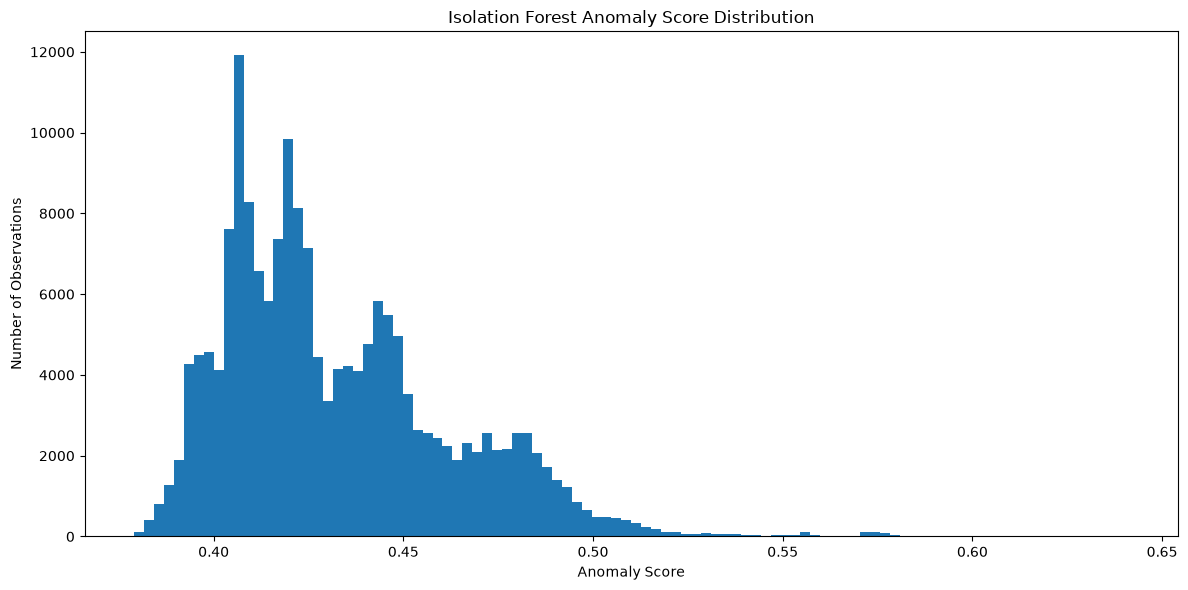

In [119]:
# ============================================================
# 28. ANOMALY SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

plt.hist(
    final_anomaly_results["anomaly_score"],
    bins=100
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Observations")
plt.title(
    "Isolation Forest Anomaly Score Distribution"
)

plt.tight_layout()
plt.show()

## 29. Anomaly Scores Over Time

The anomaly scores are plotted chronologically to identify periods where
unusual drilling behavior becomes concentrated.

Temporal clustering of anomalies can be more informative than isolated
individual observations because sustained abnormal conditions may indicate
an operational event.

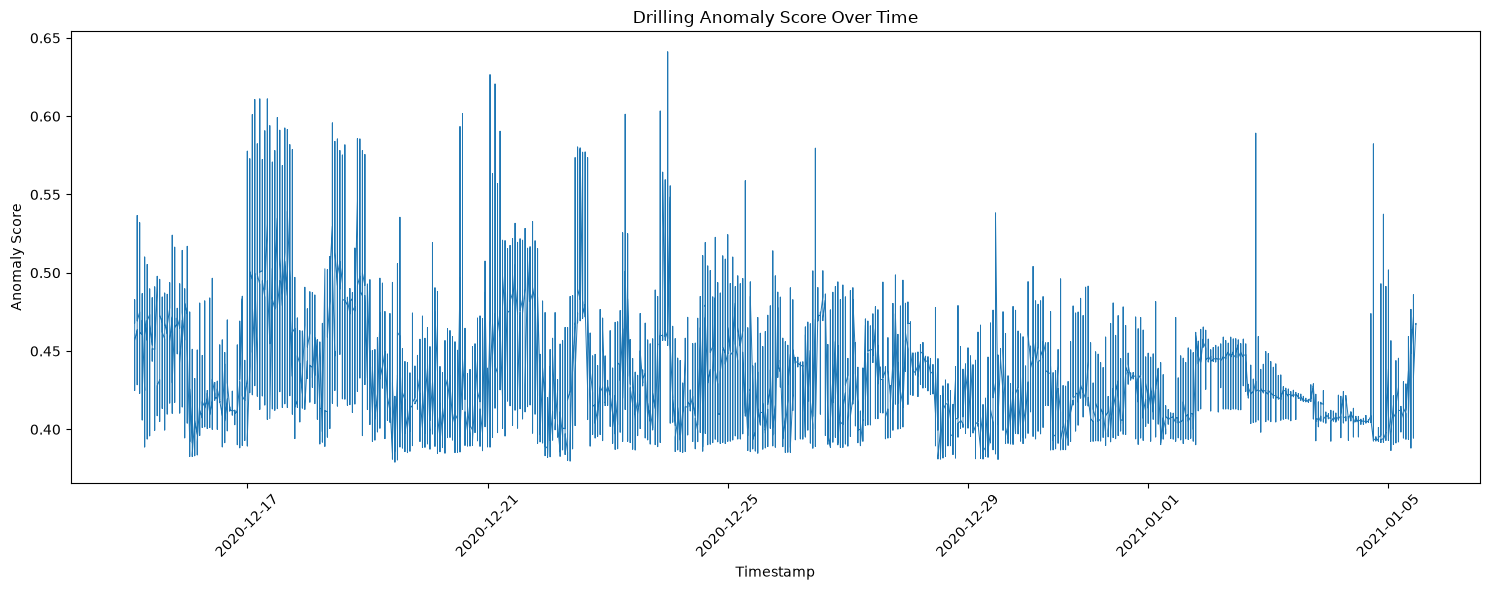

In [120]:
# ============================================================
# 29. ANOMALY SCORES OVER TIME
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    final_anomaly_results["timestamp"],
    final_anomaly_results["anomaly_score"],
    linewidth=0.7
)

plt.xlabel("Timestamp")
plt.ylabel("Anomaly Score")
plt.title(
    "Drilling Anomaly Score Over Time"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 30. Daily Anomaly Analysis

The daily anomaly rate is calculated to identify periods with unusually
high concentrations of detected anomalies.

This provides a more interpretable temporal view of the anomaly detector.

In [121]:
# ============================================================
# 30. DAILY ANOMALY ANALYSIS
# ============================================================

daily_anomalies = (
    final_anomaly_results
    .assign(
        date=final_anomaly_results[
            "timestamp"
        ].dt.date
    )
    .groupby("date")["is_anomaly"]
    .agg(
        total="count",
        anomalies="sum",
        anomaly_rate="mean"
    )
)

daily_anomalies["anomaly_rate"] *= 100

display(
    daily_anomalies
)

,total,anomalies,anomaly_rate
date,,,
2020-12-15,7266,0,0.000000
2020-12-16,8601,0,0.000000
2020-12-17,8613,76,0.882387
2020-12-18,8591,16,0.186241
2020-12-19,8596,0,0.000000
2020-12-20,8507,2,0.023510
2020-12-21,8509,5,0.058761
2020-12-22,8528,5,0.058630
2020-12-23,8534,14,0.164050


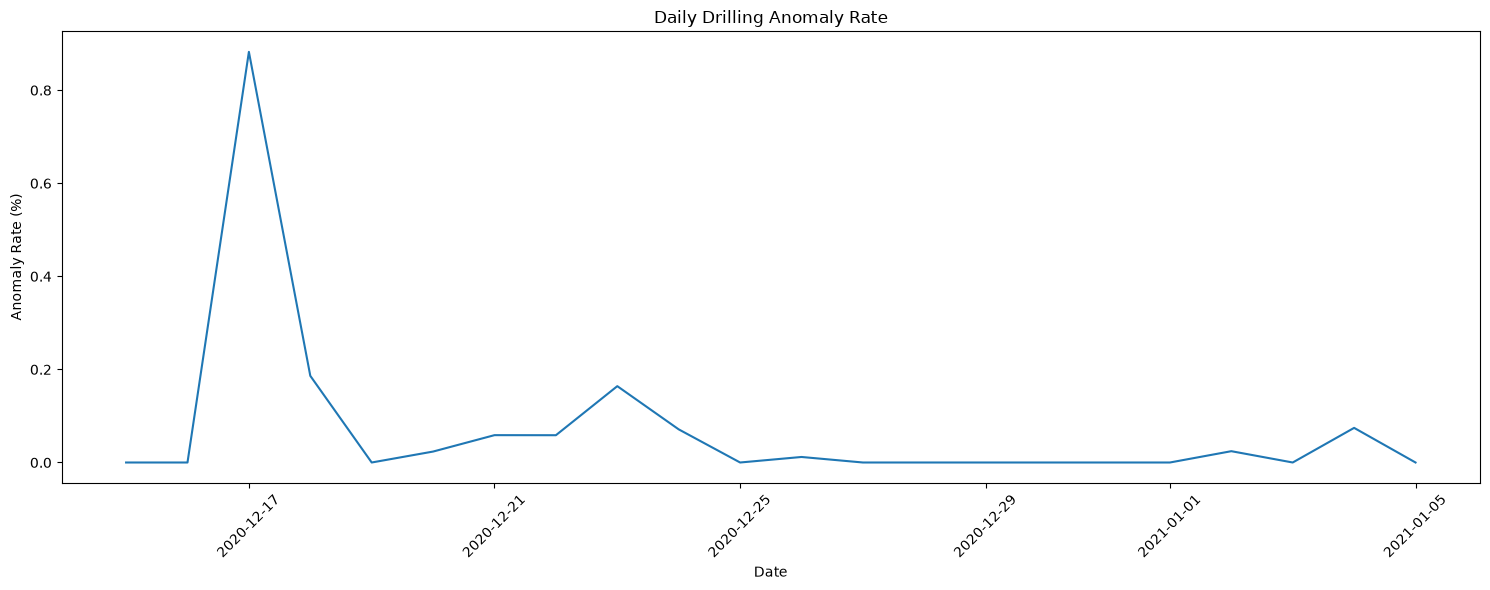

In [122]:
# ============================================================
# DAILY ANOMALY RATE
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    daily_anomalies.index,
    daily_anomalies["anomaly_rate"]
)

plt.xlabel("Date")
plt.ylabel("Anomaly Rate (%)")
plt.title(
    "Daily Drilling Anomaly Rate"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 31. Highest-Scoring Drilling Anomalies

The observations with the highest anomaly scores are extracted for detailed
inspection.

These observations represent the strongest deviations detected by the
Isolation Forest during the future scoring period.

In [123]:
# ============================================================
# 31. TOP DETECTED ANOMALIES
# ============================================================

top_anomalies = (
    final_anomaly_results[
        final_anomaly_results["is_anomaly"]
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Detected anomalies:",
    len(top_anomalies)
)

display(
    top_anomalies.head(20)
)

Detected anomalies: 133


,timestamp,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,top_drive_torque_ft_lbs,flow_in,...,mud_temp,h2s_01,rig_event_code,bit_diameter,bit_rpm,differential_pressure,downhole_torque,anomaly_score,anomaly_flag,is_anomaly
0,2020-12-24 00:00:00,54.70604,7.96525,244.20370,0.0,0.00000,1.0,41.63153,6227.1830,11087.60300,...,109.40,0.0,999.0,8.75,2724.67040,48.07716,496.84723,0.641119,1,True
1,2020-12-21 01:00:00,98.55401,44.04024,208.50722,0.0,0.00000,0.0,0.45270,6640.2520,83949.87000,...,101.10,0.0,133.0,8.75,20316.30000,1035.96260,10530.92400,0.626515,1,True
2,2020-12-24 00:00:00,55.04493,8.17636,243.94781,0.0,0.00000,1.0,41.49064,7010.7993,4159.15140,...,108.80,0.0,999.0,8.75,1048.02540,44.21230,456.56890,0.622048,1,True
3,2020-12-24 00:00:00,55.09967,8.14729,244.07576,0.0,0.00000,1.0,41.51076,6769.8423,4158.78560,...,108.80,0.0,999.0,8.75,1047.93690,43.50629,451.03790,0.620782,1,True
4,2020-12-24 00:00:00,54.37503,8.15181,244.16106,0.0,0.00000,1.0,41.47051,6249.4565,11087.48100,...,110.25,0.0,999.0,8.75,220.93835,44.56582,462.02220,0.620615,1,True
5,2020-12-21 03:00:00,92.72281,8.72606,217.33537,0.0,0.00000,0.0,37.64648,9659.3000,125837.48400,...,118.55,0.0,128.0,8.75,30490.31800,25.94000,268.92487,0.620557,1,True
6,2020-12-21 03:00:00,76.39352,8.03469,219.59573,0.0,0.00000,0.0,38.55217,8782.5410,125837.95000,...,119.25,0.0,128.0,8.75,30491.33600,25.74903,266.94507,0.614073,1,True
7,2020-12-17 05:00:00,77.75121,26.46735,208.80576,0.0,0.00000,1.0,9.28824,13403.2430,658.38750,...,122.60,0.0,999.0,8.75,168.61801,125.26373,1298.63260,0.611053,1,True
8,2020-12-17 08:00:00,10.96580,21.38310,210.51167,0.0,0.00000,1.0,4.80003,13820.3620,647.84900,...,124.45,0.0,999.0,8.75,161.57948,68.84194,713.69730,0.611049,1,True
9,2020-12-17 08:00:00,10.94174,20.92991,209.65872,0.0,0.00000,1.0,5.44407,13820.3620,646.67100,...,124.40,0.0,999.0,8.75,163.46808,62.65144,649.51920,0.610753,1,True


## 32. Drilling Parameters Associated With Anomalies

Anomaly scores alone do not explain the physical cause of an anomaly.

The major drilling parameters associated with the detected anomalies are
therefore examined to determine whether unusual pressure, torque, WOB,
hookload, flow, RPM, or other operating conditions are present.

In [124]:
# ============================================================
# 32. ANOMALIES + DRILLING PARAMETERS
# ============================================================

parameter_columns = [
    feature
    for feature in anomaly_features
    if feature in final_anomaly_results.columns
]

anomaly_parameter_table = top_anomalies[
    [
        "timestamp",
        "anomaly_score",
        "is_anomaly"
    ]
    +
    parameter_columns
]

display(
    anomaly_parameter_table.head(20)
)

,timestamp,anomaly_score,is_anomaly,block_position,weight_on_bit,hookload,slips_set,rop_depth_hour,on_bottom,top_drive_rpm,...,rig_mode,rockit_on_off,mwd_azimuth,mud_temp,h2s_01,rig_event_code,bit_diameter,bit_rpm,differential_pressure,downhole_torque
0,2020-12-24 00:00:00,0.641119,True,54.70604,7.96525,244.20370,0.0,0.00000,1.0,41.63153,...,999.0,0.0,103.44,109.40,0.0,999.0,8.75,2724.67040,48.07716,496.84723
1,2020-12-21 01:00:00,0.626515,True,98.55401,44.04024,208.50722,0.0,0.00000,0.0,0.45270,...,3.0,0.0,103.44,101.10,0.0,133.0,8.75,20316.30000,1035.96260,10530.92400
2,2020-12-24 00:00:00,0.622048,True,55.04493,8.17636,243.94781,0.0,0.00000,1.0,41.49064,...,999.0,0.0,103.44,108.80,0.0,999.0,8.75,1048.02540,44.21230,456.56890
3,2020-12-24 00:00:00,0.620782,True,55.09967,8.14729,244.07576,0.0,0.00000,1.0,41.51076,...,999.0,0.0,103.44,108.80,0.0,999.0,8.75,1047.93690,43.50629,451.03790
4,2020-12-24 00:00:00,0.620615,True,54.37503,8.15181,244.16106,0.0,0.00000,1.0,41.47051,...,999.0,0.0,103.44,110.25,0.0,999.0,8.75,220.93835,44.56582,462.02220
5,2020-12-21 03:00:00,0.620557,True,92.72281,8.72606,217.33537,0.0,0.00000,0.0,37.64648,...,3.0,0.0,103.44,118.55,0.0,128.0,8.75,30490.31800,25.94000,268.92487
6,2020-12-21 03:00:00,0.614073,True,76.39352,8.03469,219.59573,0.0,0.00000,0.0,38.55217,...,3.0,0.0,103.44,119.25,0.0,128.0,8.75,30491.33600,25.74903,266.94507
7,2020-12-17 05:00:00,0.611053,True,77.75121,26.46735,208.80576,0.0,0.00000,1.0,9.28824,...,999.0,1.0,107.64,122.60,0.0,999.0,8.75,168.61801,125.26373,1298.63260
8,2020-12-17 08:00:00,0.611049,True,10.96580,21.38310,210.51167,0.0,0.00000,1.0,4.80003,...,999.0,1.0,107.62,124.45,0.0,999.0,8.75,161.57948,68.84194,713.69730
9,2020-12-17 08:00:00,0.610753,True,10.94174,20.92991,209.65872,0.0,0.00000,1.0,5.44407,...,999.0,1.0,107.62,124.40,0.0,999.0,8.75,163.46808,62.65144,649.51920


## 33. Normal vs Anomalous Operating Conditions

The median values of the selected drilling parameters are compared between
normal and anomalous observations.

This comparison provides an interpretable summary of the operating
conditions associated with the detected anomalies.

In [125]:
# ============================================================
# 33. NORMAL VS ANOMALOUS CONDITIONS
# ============================================================

normal_data = final_anomaly_results[
    final_anomaly_results["is_anomaly"] == False
]

anomalous_data = final_anomaly_results[
    final_anomaly_results["is_anomaly"] == True
]

comparison_rows = []

for feature in anomaly_features:

    if feature not in final_anomaly_results.columns:
        continue

    comparison_rows.append({

        "Feature": feature,

        "Normal_Median":
            normal_data[feature].median(),

        "Anomalous_Median":
            anomalous_data[feature].median(),

        "Normal_Mean":
            normal_data[feature].mean(),

        "Anomalous_Mean":
            anomalous_data[feature].mean()
    })

normal_anomaly_comparison = pd.DataFrame(
    comparison_rows
)

display(
    normal_anomaly_comparison
)

,Feature,Normal_Median,Anomalous_Median,Normal_Mean,Anomalous_Mean
0,block_position,39.729930,64.02003,45.678442,51.433302
1,weight_on_bit,82.418360,23.97133,107.832430,31.904036
2,hookload,172.000410,212.81468,147.905331,205.138015
3,slips_set,0.000000,0.00000,0.440884,0.052632
4,rop_depth_hour,0.000000,0.00000,3.332130,2.968790
5,on_bottom,0.000000,1.00000,0.060971,0.887218
6,top_drive_rpm,0.291690,11.11975,10.136775,19.295799
7,top_drive_torque_ft_lbs,0.000000,2384.02220,1885.722327,4665.857257
8,flow_in,64.671990,646.50726,217.477249,6537.733952
9,pump_pressure,35.720050,4080.60570,765.646262,3427.441650


## 34. Feature-Level Deviation Analysis

The relative difference between normal and anomalous operating conditions is
calculated for each selected feature.

This helps identify which drilling parameters exhibit the largest changes
during detected anomalies.

In [126]:
# ============================================================
# 34. FEATURE-LEVEL DEVIATION
# ============================================================

deviation_df = normal_anomaly_comparison.copy()

deviation_df["absolute_difference"] = (
    deviation_df["Anomalous_Median"]
    -
    deviation_df["Normal_Median"]
).abs()

deviation_df["relative_difference_%"] = (
    deviation_df["absolute_difference"]
    /
    deviation_df["Normal_Median"].abs().replace(
        0,
        np.nan
    )
    *
    100
)

deviation_df = (
    deviation_df
    .sort_values(
        "relative_difference_%",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    deviation_df
)

,Feature,Normal_Median,Anomalous_Median,Normal_Mean,Anomalous_Mean,absolute_difference,relative_difference_%
0,rig_mode,3.000000,999.00000,149.347987,879.112782,996.000000,33200.000000
1,pump_pressure,35.720050,4080.60570,765.646262,3427.441650,4044.885650,11323.852150
2,top_drive_rpm,0.291690,11.11975,10.136775,19.295799,10.828060,3712.180740
3,bit_rpm,16.031165,167.28375,63.168212,1426.718112,151.252585,943.490913
4,flow_in,64.671990,646.50726,217.477249,6537.733952,581.835270,899.671202
5,spm_total,15.461925,154.54850,52.093753,1562.854778,139.086575,899.542424
6,rig_event_code,150.000000,999.00000,129.799246,895.090226,849.000000,566.000000
7,return_flow,8.980480,59.05308,25.120924,49.927923,50.072600,557.571533
8,differential_pressure,-898.679655,58.58076,-1030.496597,-24.376129,957.260415,106.518536
9,weight_on_bit,82.418360,23.97133,107.832430,31.904036,58.447030,70.915061


## 35. Anomaly Severity Classification

Detected anomalies are categorized into severity levels based on their
relative anomaly scores.

The severity classification is applied only to observations already
classified as anomalous.

This provides a simple operational interpretation for downstream dashboard
and reporting applications.

In [127]:
# ============================================================
# 35. ANOMALY SEVERITY
# ============================================================

final_anomaly_results["severity"] = "Normal"

if len(top_anomalies) > 0:

    anomaly_scores_only = (
        top_anomalies["anomaly_score"]
    )

    q25 = anomaly_scores_only.quantile(0.25)
    q50 = anomaly_scores_only.quantile(0.50)
    q75 = anomaly_scores_only.quantile(0.75)

    anomaly_mask = (
        final_anomaly_results["is_anomaly"]
    )

    scores = final_anomaly_results[
        "anomaly_score"
    ]

    final_anomaly_results.loc[
        anomaly_mask
        &
        (scores <= q25),
        "severity"
    ] = "Low"

    final_anomaly_results.loc[
        anomaly_mask
        &
        (scores > q25)
        &
        (scores <= q50),
        "severity"
    ] = "Moderate"

    final_anomaly_results.loc[
        anomaly_mask
        &
        (scores > q50)
        &
        (scores <= q75),
        "severity"
    ] = "High"

    final_anomaly_results.loc[
        anomaly_mask
        &
        (scores > q75),
        "severity"
    ] = "Critical"

print(
    final_anomaly_results[
        "severity"
    ].value_counts()
)

severity
Normal      179480
Low             34
High            33
Critical        33
Moderate        33
Name: count, dtype: int64


## 36. Contamination Sensitivity Analysis

Isolation Forest uses the contamination parameter to determine the anomaly
threshold.

The selected contamination value of 0.005 is therefore compared with higher
threshold settings.

This analysis evaluates whether the detected anomaly population is highly
sensitive to the assumed contamination level.

The sensitivity analysis is performed on the same scoring period and does
not retrain the final model used for deployment.

In [128]:
# ============================================================
# 36. CONTAMINATION SENSITIVITY
# ============================================================

contamination_values = [
    0.005,
    0.01,
    0.02
]

sensitivity_results = []

for contamination_value in contamination_values:

    sensitivity_model = IsolationForest(
        n_estimators=best_params[
            "n_estimators"
        ],
        max_samples=best_params[
            "max_samples"
        ],
        max_features=best_params[
            "max_features"
        ],
        contamination=contamination_value,
        random_state=42,
        n_jobs=-1
    )

    sensitivity_model.fit(
        X_reference_scaled
    )

    sensitivity_predictions = (
        sensitivity_model.predict(
            X_scoring_scaled
        )
    )

    anomaly_count = int(
        (
            sensitivity_predictions == -1
        ).sum()
    )

    anomaly_percentage = (
        anomaly_count
        /
        len(sensitivity_predictions)
        *
        100
    )

    sensitivity_results.append({

        "contamination":
            contamination_value,

        "anomaly_count":
            anomaly_count,

        "anomaly_rate_%":
            anomaly_percentage
    })

contamination_sensitivity_df = pd.DataFrame(
    sensitivity_results
)

display(
    contamination_sensitivity_df
)

,contamination,anomaly_count,anomaly_rate_%
0,0.005,133,0.074048
1,0.010,347,0.193193
2,0.020,539,0.300090


## 37. Final Isolation Forest Model Summary

The final anomaly detector uses the configuration selected during the
hyperparameter tuning stage.

The model is trained exclusively on the chronological reference period and
is evaluated on the subsequent scoring period.

The final configuration and anomaly statistics are reported below.

In [129]:
# ============================================================
# 37. FINAL MODEL SUMMARY
# ============================================================

# Recalculate final statistics directly from the
# final model's out-of-sample predictions.

final_total_scoring = len(
    final_anomaly_flags
)

final_total_anomalies = int(
    final_anomaly_flags.sum()
)

final_total_normal = (
    final_total_scoring
    -
    final_total_anomalies
)

final_anomaly_rate = (
    final_total_anomalies
    /
    final_total_scoring
    *
    100
)

print("=" * 80)
print("NOTEBOOK 5 — FINAL ISOLATION FOREST MODEL")
print("=" * 80)

print("\nSelected Hyperparameters:")

for key, value in best_params.items():
    print(
        f"  {key:<20}: {value}"
    )

print("\nDataset:")

print(
    f"  Reference observations : "
    f"{len(X_reference_scaled):,}"
)

print(
    f"  Scoring observations   : "
    f"{final_total_scoring:,}"
)

print("\nResults:")

print(
    f"  Normal observations    : "
    f"{final_total_normal:,}"
)

print(
    f"  Detected anomalies     : "
    f"{final_total_anomalies:,}"
)

print(
    f"  Anomaly rate           : "
    f"{final_anomaly_rate:.4f}%"
)

print(
    f"  Training time          : "
    f"{final_training_time:.2f} seconds"
)

NOTEBOOK 5 — FINAL ISOLATION FOREST MODEL

Selected Hyperparameters:
  n_estimators        : 300
  max_samples         : auto
  max_features        : 1.0
  contamination       : 0.005

Dataset:
  Reference observations : 419,096
  Scoring observations   : 179,613

Results:
  Normal observations    : 179,480
  Detected anomalies     : 133
  Anomaly rate           : 0.0740%
  Training time          : 1.25 seconds


## 38. Save Full Anomaly Results

The complete scoring-period results are saved for downstream analysis.

The output contains the original scoring observations together with the
Isolation Forest anomaly score, anomaly flag, and severity classification.

In [130]:
# ============================================================
# 38. SAVE FULL ANOMALY RESULTS
# ============================================================

full_results_path = (
    "drilling_anomaly_results.csv"
)

final_anomaly_results.to_csv(
    full_results_path,
    index=False
)

print(
    "Saved:",
    full_results_path
)

print(
    "Rows:",
    len(final_anomaly_results)
)

Saved: drilling_anomaly_results.csv
Rows: 179613


## 39. Dashboard-Ready Anomaly Dataset

A compact dataset is created for visualization and downstream dashboard
integration.

Only the fields required to interpret and visualize detected drilling
anomalies are retained.

In [131]:
# ============================================================
# 39. DASHBOARD-READY DATASET
# ============================================================

dashboard_columns = [
    "timestamp",
    "anomaly_score",
    "anomaly_flag",
    "is_anomaly",
    "severity"
]

# Add useful contextual fields if available
context_columns = [
    "depth_hole_tvd",
    "total_depth",
    "drill_mode",
    "rig_mode",
    "rig_event_code"
]

dashboard_columns += [
    column
    for column in context_columns
    if column in final_anomaly_results.columns
]

# Add important physical measurements
dashboard_physical_features = [
    "pump_pressure",
    "differential_pressure",
    "downhole_torque",
    "top_drive_torque_ft_lbs",
    "weight_on_bit",
    "hookload",
    "flow_in",
    "spm_total",
    "bit_rpm",
    "rop_depth_hour"
]

dashboard_columns += [
    column
    for column in dashboard_physical_features
    if column in final_anomaly_results.columns
]

dashboard_columns = list(
    dict.fromkeys(
        dashboard_columns
    )
)

dashboard_anomaly_results = (
    final_anomaly_results[
        dashboard_columns
    ]
    .copy()
)

dashboard_path = (
    "drilling_anomaly_dashboard.csv"
)

dashboard_anomaly_results.to_csv(
    dashboard_path,
    index=False
)

print(
    "Saved:",
    dashboard_path
)

print(
    "Dashboard rows:",
    len(dashboard_anomaly_results)
)

print(
    "Dashboard columns:",
    len(dashboard_anomaly_results.columns)
)

Saved: drilling_anomaly_dashboard.csv
Dashboard rows: 179613
Dashboard columns: 17


## 40. Save Anomaly Detection Model

The final tuned Isolation Forest is saved for future inference.

The preprocessing objects are also saved so that new drilling observations
can be transformed using the same preprocessing procedure used during
training.

In [137]:
# ============================================================
# 40. SAVE FINAL ISOLATION FOREST MODEL
# ============================================================

import joblib
import os

model_artifact = {
    "model": final_iso_model,
    "imputer": imputer,
    "scaler": scaler,
    "features": numeric_features,
    "best_params": best_params
}

# ------------------------------------------------------------
# Save as JOBLIB
# ------------------------------------------------------------

joblib_path = (
    "isolation_forest_drilling_anomaly_model.joblib"
)

joblib.dump(
    model_artifact,
    joblib_path
)

# ------------------------------------------------------------
# Save as PKL
# ------------------------------------------------------------

pkl_path = (
    "isolation_forest_drilling_anomaly_model.pkl"
)

joblib.dump(
    model_artifact,
    pkl_path
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("=" * 70)
print("MODEL ARTIFACTS SAVED")
print("=" * 70)

print(
    f"✓ JOBLIB: {joblib_path}"
)

print(
    f"✓ PKL   : {pkl_path}"
)

print(
    f"\nJOBLIB exists: {os.path.exists(joblib_path)}"
)

print(
    f"PKL exists   : {os.path.exists(pkl_path)}"
)

MODEL ARTIFACTS SAVED
✓ JOBLIB: isolation_forest_drilling_anomaly_model.joblib
✓ PKL   : isolation_forest_drilling_anomaly_model.pkl

JOBLIB exists: True
PKL exists   : True


## 41. Save Model Metadata

Metadata records the model configuration, feature set, reference period,
scoring period, and final anomaly statistics.

This supports reproducibility and future deployment.

In [141]:
# ============================================================
# 41. SAVE MODEL METADATA
# ============================================================

metadata = {
    "model": "Isolation Forest",

    "n_estimators":
        best_params["n_estimators"],

    "max_samples":
        best_params["max_samples"],

    "max_features":
        best_params["max_features"],

    "contamination":
        best_params["contamination"],

    "features":
        numeric_features,
    "reference_start":
        str(
            reference_df["timestamp"].min()
        ),

    "reference_end":
        str(
            reference_df["timestamp"].max()
        ),

    "scoring_start":
        str(
            scoring_df["timestamp"].min()
        ),

    "scoring_end":
        str(
            scoring_df["timestamp"].max()
        ),

    "reference_rows":
        len(reference_df),

    "scoring_rows":
        len(scoring_df),

    "anomaly_count":
        final_total_anomalies,

    "anomaly_rate_percent":
        final_anomaly_rate,

    "training_time_seconds":
        final_training_time
}

metadata_path = (
    "drilling_anomaly_model_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4,
        default=str
    )

print(
    "Saved:",
    metadata_path
)

Saved: drilling_anomaly_model_metadata.json


## 42. Output File Verification

The expected deployment artifacts are verified after model training and
result generation.

The verification confirms that the files exist and contain the expected
number of observations.

In [142]:
# ============================================================
# 42. OUTPUT VERIFICATION
# ============================================================

import os

expected_outputs = [
    full_results_path,
    dashboard_path,
    joblib_path,
    pkl_path,
    metadata_path
]

print("=" * 70)
print("OUTPUT FILE VERIFICATION")
print("=" * 70)

for output_file in expected_outputs:

    exists = os.path.exists(
        output_file
    )

    if exists:

        size_mb = (
            os.path.getsize(
                output_file
            )
            /
            (1024 ** 2)
        )

        print(
            f"✓ {output_file:<55}"
            f"{size_mb:.2f} MB"
        )

    else:

        print(
            f"✗ {output_file}"
        )

print("\n" + "=" * 70)
print("MODEL ARTIFACT VERIFICATION")
print("=" * 70)

print(
    f"✓ JOBLIB: {joblib_path}"
    if os.path.exists(joblib_path)
    else f"✗ JOBLIB: {joblib_path}"
)

print(
    f"✓ PKL   : {pkl_path}"
    if os.path.exists(pkl_path)
    else f"✗ PKL   : {pkl_path}"
)

OUTPUT FILE VERIFICATION
✓ drilling_anomaly_results.csv                           38.52 MB
✓ drilling_anomaly_dashboard.csv                         24.83 MB
✓ isolation_forest_drilling_anomaly_model.joblib         3.25 MB
✓ isolation_forest_drilling_anomaly_model.pkl            3.25 MB
✓ drilling_anomaly_model_metadata.json                   0.00 MB

MODEL ARTIFACT VERIFICATION
✓ JOBLIB: isolation_forest_drilling_anomaly_model.joblib
✓ PKL   : isolation_forest_drilling_anomaly_model.pkl


## 43. Model Artifact and Metadata Integrity Check

The generated model artifacts and metadata file are reloaded after saving to
verify that they can be successfully read and used.

The `.pkl` and `.joblib` files should contain the trained Isolation Forest,
preprocessing objects, selected features, and final hyperparameters.

The `.json` file should contain the model configuration, feature list,
reference/scoring periods, and final anomaly statistics.

This provides a final reproducibility and deployment-readiness check.

In [143]:
# ============================================================
# 43. MODEL ARTIFACT AND METADATA INTEGRITY CHECK
# ============================================================

import joblib
import json
import os

print("=" * 70)
print("MODEL ARTIFACT AND METADATA INTEGRITY CHECK")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOAD PKL
# ------------------------------------------------------------

print("\n[1] PKL MODEL")

loaded_pkl = joblib.load(
    pkl_path
)

print("✓ PKL loaded successfully")

print("\nStored components:")

for key in loaded_pkl.keys():
    print(f"  - {key}")


# ------------------------------------------------------------
# 2. LOAD JOBLIB
# ------------------------------------------------------------

print("\n[2] JOBLIB MODEL")

loaded_joblib = joblib.load(
    joblib_path
)

print("✓ JOBLIB loaded successfully")

print("\nStored components:")

for key in loaded_joblib.keys():
    print(f"  - {key}")


# ------------------------------------------------------------
# 3. VERIFY MODEL CONFIGURATION
# ------------------------------------------------------------

print("\n[3] MODEL CONFIGURATION")

print(
    "Number of stored features:",
    len(loaded_pkl["features"])
)

print(
    "Stored hyperparameters:",
    loaded_pkl["best_params"]
)

print(
    "✓ Model configuration verified"
)


# ------------------------------------------------------------
# 4. LOAD JSON METADATA
# ------------------------------------------------------------

print("\n[4] JSON METADATA")

with open(
    metadata_path,
    "r"
) as f:

    loaded_metadata = json.load(f)

print("✓ JSON loaded successfully")

print("\nMetadata fields:")

for key in loaded_metadata.keys():
    print(f"  - {key}")


# ------------------------------------------------------------
# 5. VERIFY KEY METADATA
# ------------------------------------------------------------

print("\n[5] METADATA VERIFICATION")

print(
    "Model:",
    loaded_metadata.get("model")
)

print(
    "Contamination:",
    loaded_metadata.get("contamination")
)

print(
    "Anomaly count:",
    loaded_metadata.get("anomaly_count")
)

print(
    "Anomaly rate:",
    loaded_metadata.get(
        "anomaly_rate_percent"
    )
)

print(
    "Reference rows:",
    loaded_metadata.get(
        "reference_rows"
    )
)

print(
    "Scoring rows:",
    loaded_metadata.get(
        "scoring_rows"
    )
)


# ------------------------------------------------------------
# 6. FINAL INTEGRITY RESULT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INTEGRITY CHECK RESULT")
print("=" * 70)

print("✓ PKL artifact loaded successfully")
print("✓ JOBLIB artifact loaded successfully")
print("✓ JSON metadata loaded successfully")
print("✓ Model configuration is readable")
print("✓ Metadata is readable")

print(
    "\n✓ All model artifacts passed the integrity check."
)

MODEL ARTIFACT AND METADATA INTEGRITY CHECK

[1] PKL MODEL
✓ PKL loaded successfully

Stored components:
  - model
  - imputer
  - scaler
  - features
  - best_params

[2] JOBLIB MODEL
✓ JOBLIB loaded successfully

Stored components:
  - model
  - imputer
  - scaler
  - features
  - best_params

[3] MODEL CONFIGURATION
Number of stored features: 25
Stored hyperparameters: {'n_estimators': 300, 'max_samples': 'auto', 'max_features': 1.0, 'contamination': 0.005}
✓ Model configuration verified

[4] JSON METADATA
✓ JSON loaded successfully

Metadata fields:
  - model
  - n_estimators
  - max_samples
  - max_features
  - contamination
  - features
  - reference_start
  - reference_end
  - scoring_start
  - scoring_end
  - reference_rows
  - scoring_rows
  - anomaly_count
  - anomaly_rate_percent
  - training_time_seconds

[5] METADATA VERIFICATION
Model: Isolation Forest
Contamination: 0.005
Anomaly count: 133
Anomaly rate: 0.0740480922873066
Reference rows: 419096
Scoring rows: 179613

INT

# 44. Notebook 5 — Final Conclusion

## Objective

Notebook 5 developed an unsupervised Isolation Forest model for detecting
unusual drilling conditions from drilling data.

## Final Methodology

The workflow included:

1. Timestamp preparation
2. Candidate feature identification
3. Feature filtering
4. Removal of drilling progression/context-heavy variables
5. Missing-value handling
6. Robust scaling
7. Chronological reference/scoring split
8. Isolation Forest hyperparameter tuning
9. Automatic best-model selection
10. Out-of-sample anomaly detection
11. Temporal anomaly analysis
12. Anomaly severity classification
13. Feature-level interpretation
14. Dashboard-ready dataset generation
15. Model and metadata export
16. Artifact integrity verification

## Final Model

The selected Isolation Forest configuration was:

- Number of estimators: 300
- Maximum samples: auto
- Maximum features: 1.0
- Contamination: 0.005

## Final Out-of-Sample Result

The scoring period contained 179,613 observations.

The final model identified 133 observations as anomalous.

This corresponds to an out-of-sample anomaly rate of 0.0740%.

## Model Artifacts

The following deployment artifacts were generated:

- `drilling_anomaly_results.csv`
- `drilling_anomaly_dashboard.csv`
- `isolation_forest_drilling_anomaly_model.joblib`
- `isolation_forest_drilling_anomaly_model.pkl`
- `drilling_anomaly_model_metadata.json`

All generated model artifacts and metadata were successfully reloaded and
passed the final integrity check.

## Interpretation

The initial anomaly detector produced an unrealistically high anomaly rate
because variables describing drilling progression and contextual state were
included as anomaly-detection features.

After removing these progression-heavy variables, the out-of-sample anomaly
rate decreased substantially.

The final detector therefore provides a more selective identification of
observations that differ from the learned reference drilling conditions.

The detected observations should be interpreted as model-detected drilling
anomalies rather than confirmed equipment failures. Domain validation is
required before treating individual anomalies as confirmed operational
events.